In [1]:
import matplotlib as plt
from rotations import rot_z
from helpers import load_dataloader, predict, rotate_image, optimize_latents_of_image, lerp
from reni.utils.utils import find_nerfstudio_project_root
from reni.utils.colourspace import linear_to_sRGB

import os
from pathlib import Path
from helpers import models
from veni.utils.helpers import load_model, device
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib import gridspec
from PIL import Image
import numpy as np
import statistics
import pickle

project_root = find_nerfstudio_project_root(Path(os.getcwd()))
os.chdir(project_root)

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{extpfeil}",
    "font.family": "serif",
})

In [2]:
dataloader_mode = "test"
test_dataloader, metadata, num_train_data, num_eval_data = load_dataloader(dataloader_mode)
H, W = metadata["image_height"], metadata["image_width"]    


Setting up training dataset...

Caching all 3346 images.

Warning: If you run out of memory, try reducing the number of images to sample from.

Output()

Warning: Some cameras are equirectangular, but using default pixel sampler.

Setting up evaluation dataset...

Caching all 21 images.

Output()

Warning: Some cameras are equirectangular, but using default pixel sampler.

In [3]:
import torch
import torch.nn.functional as F

def rotate_image(img, angle):
    H, W, C = img.shape
    shift_px = (angle/360)*W
    img = img.permute(2, 0, 1).unsqueeze(0)  # (1, C, H, W)

    # Normalized horizontal shift: 1.0 corresponds to full width
    shift_norm = shift_px / W

    # Create base sampling grid
    xs = torch.linspace(-1, 1, W)
    ys = torch.linspace(-1, 1, H)
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing="ij")

    # Apply normalized horizontal translation
    grid_x = grid_x + 2 * shift_norm  # because grid runs from -1 to 1

    # Wrap-around: cyclic longitude
    grid_x = (grid_x + 1) % 2 - 1

    grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)

    # Bilinear sampling
    rotated = F.grid_sample(
        img, grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=False
    )

    return rotated.squeeze(0).permute(1, 2, 0)

using VENI
ENCODER_PARAMETERS 21095624


/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/proj/ciptmp/ym26efer/ns5/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


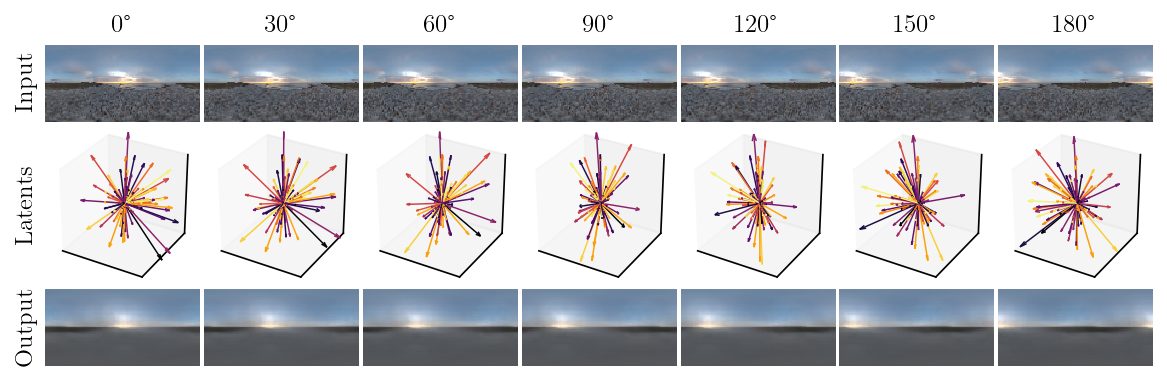

In [4]:
import pyexr
import cv2
import matplotlib.animation as animation 
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

test_dataloader.count = 0
camera, batch = next(test_dataloader)
output = []
num_eval = len(test_dataloader)


environment_map = Path("data/RENI_HDR/test/00019.exr") 
model_path = Path("outputs/veni/veni_300")
steps = 7
stepwidth = 30 #360/64*4

environment_map = pyexr.read(str(environment_map.absolute())).astype("float32")
environment_map[environment_map == np.inf] = np.nanmax(environment_map[environment_map != np.inf])
# make any values less than zero equal to min non negative
if np.any(environment_map>0):
    environment_map[environment_map <= 0] = np.nanmin(environment_map[environment_map > 0])

environment_map = cv2.resize(environment_map, (128,64), interpolation=cv2.INTER_LINEAR)
environment_map = torch.tensor(environment_map).float()[...,:3]
environment_map = torch.log(environment_map+1e-8)


model, pipeline_config = load_model(Path(model_path), model_only=True, metadata=metadata, model_type="VENI")

image = rotate_image(environment_map,0)
latents,pred,_,_ = predict(camera, model, batch={"image": image}, latents=None)

image = torch.exp(image)
image = linear_to_sRGB(image, use_quantile=True)
pred = torch.exp(pred["rgb"])
pred = linear_to_sRGB(pred, use_quantile=True).squeeze(0).cpu()


figsize_mult = 0.4
fig = plt.figure(figsize=(17/5*steps*figsize_mult,7*figsize_mult), dpi=150)
#fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=None, hspace=None)
gs0 = gridspec.GridSpec(3,steps, figure=fig, wspace=0.03, hspace=0.03, height_ratios=[1,2,1])

ax = fig.add_subplot(gs0[0,:])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('Input', fontsize=12)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax = fig.add_subplot(gs0[1,:])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('Latents', fontsize=12)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

ax = fig.add_subplot(gs0[2,:])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('Output', fontsize=12)
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

for step in range(steps):
    angle = step*stepwidth
    image = rotate_image(environment_map,angle)
    latents,pred,_,_ = predict(camera, model, batch={"image": image}, latents=None)
    image = torch.exp(image)
    q = torch.quantile(image.flatten(), 0.995)
    image = linear_to_sRGB(image, q=q)
    pred = torch.exp(pred["rgb"])
    pred = linear_to_sRGB(pred.cpu(), q=q).squeeze(0)
    latents = latents.squeeze(0).cpu()


    ax = fig.add_subplot(gs0[0,step])
    ax.imshow(image,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f"{angle}°", fontsize=12)
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    
    latents = latents.cpu().squeeze(0)
    origins = torch.zeros_like(latents).cpu()
    ax = fig.add_subplot(gs0[1,step], projection='3d')
    torch.manual_seed(42)
    color_indices = torch.rand(latents.shape[0])
    colormap = cm.inferno
    
    vec = ax.quiver(
        origins[:, 0], origins[:, 1], origins[:, 2],
        latents[:, 0], -latents[:, 1], latents[:, 2], color=colormap(color_indices),
        linewidth = 0.7, arrow_length_ratio=0.1
    )
    lim = torch.max(latents.norm(dim=-1)).cpu()*0.6
    ax.set_xlim([-lim, lim])
    ax.set_ylim([-lim, lim])
    ax.set_zlim([-lim, lim])
    ax.set_box_aspect([1, 1, 1])  # equal aspect ratio
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')

    
    ax = fig.add_subplot(gs0[2,step])
    ax.imshow(pred,interpolation='none')
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    
plt.savefig("publication/figures/rebuttal_equivariance.pdf",bbox_inches='tight', pad_inches=0.05)    
plt.show()

